# Basic Concepts

## Import and Formatting

The goal of this section is to import all the necessary files and libraries required for the subsequent data analysis.  
It also includes setting up the formatting parameters for the plots and visualizations.

### Import

In [1]:
# ----  Standard import
import matplotlib.pyplot as plt
import numpy as np

# ----- Spice import
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

### Formatting

Adjusting Plotly chart settings for clarity and consistency.

In [2]:
# ----  Formatting charts
%matplotlib inline
from IPython.core.pylabtools import figsize
import matplotlib as mpl
mpl.rcParams['lines.linewidth'] = 2.0
mpl.rcParams['axes.edgecolor']  = "#bcbcbc"
mpl.rcParams['patch.linewidth'] = 0.5
mpl.rcParams['legend.fancybox'] = True
mpl.rcParams['axes.facecolor']  = "#eeeeee"
mpl.rcParams['axes.labelsize']  = "large"
mpl.rcParams['axes.grid']       = True
mpl.rcParams['grid.linestyle']  = "--"
mpl.rcParams['patch.edgecolor'] = "#eeeeee"
mpl.rcParams['axes.titlesize']  = "x-large"

## Definition of Fundamental Electrical Parameters

The objective of this notebook is to study the fundamental parameters of electronics. There are four variables that govern electronic circuits. These parameters are:

* Voltage ($V$)
* Current ($I$)
* Charge ($q$)
* Flux ($\phi$)

### Electrical Voltage

**Electrical voltage** is a fundamental quantity that characterizes the energetic state of an electrical circuit.

> Electrical voltage represents the **electric potential difference** between two points in a circuit. It is expressed in volts (V) and corresponds to the energy exchanged per unit charge when a charge moves between these two points.

Intuitively, voltage can be seen as the **driving cause** of electric charge motion: the higher the voltage, the greater the “driving force” pushing the charges, allowing electrical devices to operate.

```{note}
In electrostatics (static regime), the concept of voltage is strictly equivalent to that of electric potential difference between two points.
However, in the dynamic regime (time-varying currents and fields), this equivalence no longer always holds: electromagnetic induction phenomena require a rigorous distinction between these concepts.
```

The unit of voltage is the **volt**, denoted $V$.

### Electric Current

**Electric current** describes the collective motion of electric charges within a conducting material.

> An electric current corresponds to the **ordered motion of charge carriers**, generally electrons, under the action of an electric field. This motion results from the electromagnetic force and constitutes the observable manifestation of electricity in circuits.

From a quantitative standpoint, electric current measures the **amount of electric charge passing through a cross-section of a conductor per unit time**.

The unit of electric current is the **ampere**, denoted $A$.

### Electric Charges

**Electric charge** is an intrinsic and fundamental property of matter.

> Electric charge is a scalar quantity that characterizes the ability of matter to interact through electromagnetic fields. For electromagnetic interaction, it plays a role analogous to that of mass in gravitational interaction.

There are **two types of electric charges**, distinguished by their sign:

* **positive** charges,
* **negative** charges.

Charges with the same sign repel each other, while charges with opposite signs attract each other.
In ordinary matter, positive and negative charges are generally present in equal amounts, leading to a state of **electrical neutrality**.

The unit of electric charge is the **coulomb**, denoted ( C ).

### Electric Flux

**Electric flux** is a quantity from electromagnetism associated with the electric field.

> Electric flux represents the **measure of the electric field passing through a given surface**. It depends on both the magnitude of the field, the orientation of the surface, and its geometry.

This concept plays a central role in the formulation of the fundamental laws of electromagnetism, particularly **Gauss’s law**, which relates electric flux to the electric charge enclosed by a closed surface.

## Relationship

### Voltage / Current

This relationship is the simplest one. According to Ohm’s law, it can be written as:

$$U = R \cdot I$$

where:

* (U) represents the voltage in volts (V),
* (I) represents the current in amperes (A),
* (R) represents the resistance in ohms (Ω).

This equation shows that there is a **linear relationship** between voltage and current through a resistor.

Another equivalent relationship can be written as:

$$dV = R \cdot dI$$

The relation remains the same, but in this case, it takes into account that the current may vary with time. This time-dependent behavior is not explicitly considered in the first equation.

In the next section, this relationship will be further analyzed and extended to more complex components and systems.

In [3]:
# Create the electrical circuit
circuit = Circuit('Resistor')

# Sinusoidal voltage source connected to ground
circuit.SinusoidalVoltageSource(
    'in',
    'input',
    circuit.gnd,
    amplitude=1 @ u_V,
    frequency=1 @ u_kHz,
    offset=0 @ u_V
)

# Resistor connected between input and ground
circuit.R(1, 'input', circuit.gnd, 10 @ u_Ohm)

# Add a current probe to measure the resistor current
circuit.R1.minus.add_current_probe(circuit)

In [4]:
# Create the simulator
simulator = circuit.simulator(
    temperature=25,
    nominal_temperature=25
)

# Run a transient analysis
analysis = simulator.transient(
    step_time=0.001 @ u_ms,
    end_time=10 @ u_ms,
    use_initial_condition=True
)

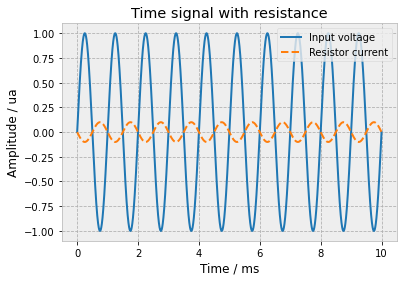

In [5]:
# Plot voltage and current versus time
plt.figure()
plt.title("Time signal with resistance")
plt.plot(analysis.time*1e3, analysis['input'], label='Input voltage')
plt.plot(analysis.time*1e3, analysis.branches['vr1_minus'], '--', label='Resistor current')
plt.ylabel("Amplitude / ua")
plt.xlabel("Time / ms")
plt.legend()
plt.show()

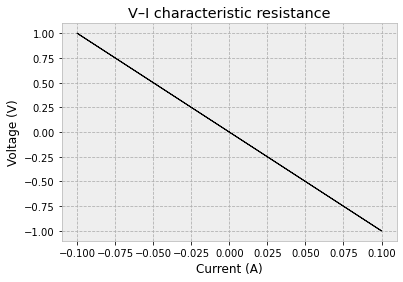

In [6]:
# Plot voltage as a function of current (V–I characteristic)
plt.figure()
plt.title("V–I characteristic resistance")
plt.plot(
    analysis.branches['vr1_minus'],
    analysis['input'],
    lw=1,
    c = "black"
)
plt.xlabel("Current (A)")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.show()

### Current / Charge

Current and electric charge are related by the following fundamental relation:

$$i(t) = \frac{dq(t)}{dt}$$

The inverse relation is therefore an integral:

$$q(t) = q(t_0) + \int i(t), dt$$

where:

* $q$ is the electric charge (in coulombs [C])
* $i$ is the charge flow rate (in amperes [A = C/s])

### Voltage / Charge

The relationship between charge and voltage is defined by the capacitance.

The basic equation is:

$$Q = C \cdot V$$

where:

* $Q$ is the electric charge (in coulombs [C])
* $C$ is the capacitance value (in farads [F])
* $V$ is the voltage (in volts [V])

As with the voltage–current relationship, the dynamic form can be written as:

$$dq = C \cdot dv$$

To obtain the time-domain equation of a capacitor, we write:

$$q(t) = C \cdot v(t)$$

By differentiating with respect to time, we obtain:

$$\frac{dq(t)}{dt} = C \cdot \frac{dv(t)}{dt}$$

From the previous section, we know that:

$$i(t) = \frac{dq(t)}{dt}$$

Therefore, the fundamental capacitor equation is recovered:

$$i(t) = C \cdot \frac{dv(t)}{dt}$$

This equation directly describes the **current–voltage relationship of a capacitor**.

In [7]:
# Create the electrical circuit
circuit = Circuit('Capacitor')

# Sinusoidal voltage source connected to ground
circuit.SinusoidalVoltageSource('in', 'input', circuit.gnd, 
                                amplitude=1@u_V, frequency=1@u_kHz)

# Capacitor connected between input and ground
circuit.C(1, 'input', circuit.gnd, 10@u_uF)

# Add a current probe to measure the resistor current
circuit.C1.minus.add_current_probe(circuit);

In [8]:
# Create the simulator
simulator = circuit.simulator(
    temperature=25,
    nominal_temperature=25
)

# Run a transient analysis
analysis = simulator.transient(
    step_time=0.001 @ u_ms,
    end_time=10 @ u_ms,
    use_initial_condition=True
)

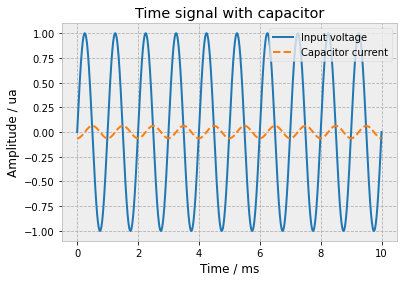

In [9]:
# Plot voltage and current versus time
plt.figure()
plt.title("Time signal with capacitor")
plt.plot(analysis.time*1e3, analysis['input'], label='Input voltage')
plt.plot(analysis.time*1e3, analysis.branches['vc1_minus'], '--', label='Capacitor current')
plt.ylabel("Amplitude / ua")
plt.xlabel("Time / ms")
plt.legend()
plt.show()

It is possible to see the current/voltage phase shift of 90°

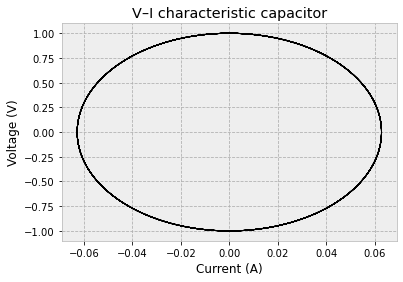

In [10]:
# Plot voltage as a function of current (V–I characteristic)
plt.figure()
plt.title("V–I characteristic capacitor")
plt.plot(
    analysis.branches['vc1_minus'],
    analysis['input'],
    lw=1,
    c = "black"
)
plt.xlabel("Current (A)")
plt.ylabel("Voltage (V)")
plt.show()

To understand the shape of the graph, we start again from the capacitor equation:

$$i(t) = C \cdot \frac{dv(t)}{dt}$$

First, the input voltage is assumed to be sinusoidal:

$$v(t) = V_0 \cos(\omega t)$$

Injecting this expression into the current equation gives:

$$i(t) = C V_0 \cdot \frac{d}{dt}\cos(\omega t)$$

$$i(t) = - C V_0 \omega \sin(\omega t)$$

The objective is now to **eliminate time** from the equations.

From the voltage expression:

$$\cos(\omega t) = \frac{v(t)}{V_0}$$

And from the current expression:

$$\sin(\omega t) = -\frac{i(t)}{C V_0 \omega}$$

Next, we square both equations:

$$\cos^2(\omega t) = \left(\frac{v(t)}{V_0}\right)^2$$

$$\sin^2(\omega t) = \left(\frac{i(t)}{C V_0 \omega}\right)^2$$

By adding $\cos^2(\omega t)$ and $\sin^2(\omega t)$, we use the trigonometric identity:

$$\cos^2(\omega t) + \sin^2(\omega t) = 1$$

which leads to:

$$\left(\frac{v(t)}{V_0}\right)^2 + \left(\frac{i(t)}{C V_0 \omega}\right)^2 = 1$$

This is exactly the equation of an **ellipse**.

With the normalized variables:

* $x = \dfrac{v(t)}{V_0}$
* $y = \dfrac{i(t)}{C V_0 \omega}$

the trajectory in the $(v, i)$ plane is an ellipse, which explains the shape observed in the graph.

**Physical interpretation:**
This elliptical Lissajous curve reflects the **90° phase shift** between voltage and current in an ideal capacitor.

In [11]:
# =========================
# Parameters
# =========================
V0 = 1.0        # Voltage amplitude [V]
C = 10e-6       # Capacitance [F]
f = 1e3         # Base frequency [Hz]
omega = 2 * np.pi * f  # Angular frequency [rad/s]

# Time vector (10 ms duration)
t = np.linspace(0, 10e-3, 1000)

In [12]:
# =========================
# Voltage and current for ω
# =========================
v1 = V0 * np.cos(omega * t)
i1 = omega * C * V0 * np.sin(omega * t)

# =========================
# Voltage and current for 2ω
# =========================
v2 = V0 * np.cos(2 * omega * t)
i2 = 2 * omega * C * V0 * np.sin(2 * omega * t)

# =========================
# Voltage and current for 10ω
# =========================
v10 = V0 * np.cos(10 * omega * t)
i10 = 10 * omega * C * V0 * np.sin(10 * omega * t)

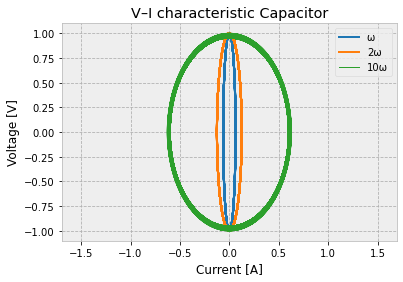

In [13]:
# =========================
# Plot: I–V characteristic
# =========================
plt.figure()

plt.title("V–I characteristic Capacitor")

plt.plot(i1, v1, label="ω")
plt.plot(i2, v2, label="2ω")
plt.plot(i10, v10, label="10ω", lw=1)

plt.xlabel("Current [A]")
plt.ylabel("Voltage [V]")
plt.legend()
plt.axis("equal")  # Ensures correct ellipse shape
plt.grid(True)
plt.show()

### Voltage / Flux

A reasoning similar to the one used for capacitors can be applied to the relationship between **magnetic flux** and **voltage**.

The fundamental relation is:

$$v(t) = \frac{d\phi(t)}{dt}$$

where:

* $\phi(t)$ is the **linked magnetic flux** (in webers [Wb]),
* $v(t)$ is the **voltage across the inductor** (in volts [V]).

This equation can be inverted by integration:

$$\phi(t) = \int v(t), dt + \phi(t_0)$$

This expression shows that the magnetic flux is the **time integral of the applied voltage**, up to an initial condition.

### Flux / Current

The basic constitutive law of an inductor is:

$$\phi(t) = L, i(t)$$

where:

* $\phi(t)$ is the linked magnetic flux (in webers [Wb]),
* $i(t)$ is the current flowing through the inductor (in amperes [A]),
* $L$ is the inductance (in henries [H]).

To obtain the current–voltage relationship, we follow the same steps as before.

Starting from:

$$\phi(t) = L, i(t)$$

and differentiating with respect to time:

$$\frac{d\phi(t)}{dt} = L \frac{di(t)}{dt}$$

From the previous section, we know that:

$$v(t) = \frac{d\phi(t)}{dt}$$

By substitution, we obtain the fundamental equation of an inductor:

$$v(t) = L \frac{di(t)}{dt}$$

This equation shows that the voltage across an inductor is proportional to the **rate of change of the current**.

In [14]:
# Create the electrical circuit
circuit = Circuit('Inductor')

# Sinusoidal current source connected to ground
circuit.SinusoidalCurrentSource('in', 'input', circuit.gnd, 
                                amplitude=1@u_A, frequency=1@u_kHz)

# Inductor connected between input and ground
circuit.L(1, 'input', circuit.gnd, 10@u_uH)
circuit.L1.minus.add_current_probe(circuit);

In [15]:
# Create the simulator
simulator = circuit.simulator(
    temperature=25,
    nominal_temperature=25
)

# Run a transient analysis
analysis = simulator.transient(
    step_time=0.001 @ u_ms,
    end_time=10 @ u_ms,
    use_initial_condition=True
)

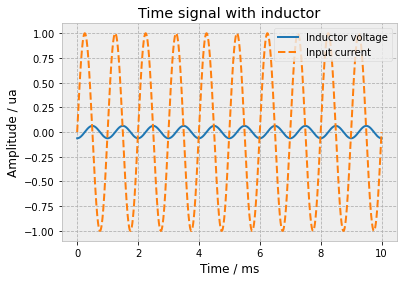

In [16]:
# Plot voltage and current versus time
plt.figure()
plt.title("Time signal with inductor")
plt.plot(analysis.time*1e3, analysis['input'], label='Inductor voltage')
plt.plot(analysis.time*1e3, analysis.branches['vl1_minus'], '--', label='Input current')
plt.ylabel("Amplitude / ua")
plt.xlabel("Time / ms")
plt.legend()
plt.show()

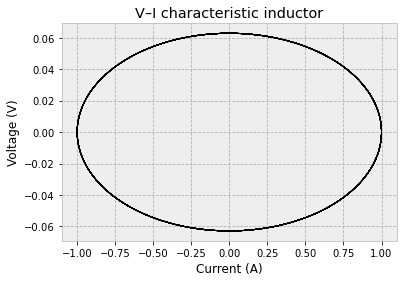

In [17]:
# Plot voltage as a function of inductor (V–I characteristic)
plt.figure()

plt.title("V–I characteristic inductor")

plt.plot(
    analysis.branches['vl1_minus'],
    analysis['input'],
    lw=1,
    c = "black"
)
plt.xlabel("Current (A)")
plt.ylabel("Voltage (V)")
plt.show()

It is possible to see the same shape as for capacitors, but this time it is **rotated by 90°**. In the next section, the goal will be to analyze this **theoretically**.

To understand the graph, we start from the inductor’s fundamental equation:

$$v(t) = L \cdot \frac{di(t)}{dt}$$

Suppose the input current is sinusoidal:

$$i(t) = I_0 \cos(\omega t)$$

Substituting into the voltage equation:

$$v(t) = L \ I_0 \cdot \frac{d}{dt} \cos(\omega t)$$

$$v(t) = - L \ I_0 \ \omega \ \sin(\omega t)$$

Next, we want to **eliminate the explicit time variable**:

$$\cos(\omega t) = \frac{i(t)}{I_0}, \quad \sin(\omega t) = -\frac{v(t)}{L I_0 \omega}$$

Squaring both equations:

$$
\cos^2(\omega t) = \left(\frac{i(t)}{I_0}\right)^2, \quad
\sin^2(\omega t) = \left(-\frac{v(t)}{L I_0 \omega}\right)^2
$$

Adding them together:

$$
\cos^2(\omega t) + \sin^2(\omega t) =
\left(\frac{i(t)}{I_0}\right)^2 + \left(\frac{v(t)}{L I_0 \omega}\right)^2 = 1
$$

We obtain the **equation of an ellipse**.

With the definitions:

* $x = \left(\dfrac{v(t)}{L I_0 \omega}\right)^2$
* $y = \left(\dfrac{i(t)}{I_0}\right)^2$

we can now plot or analyze the ellipse using these parameters.

In [18]:
# =========================
# Parameters
# =========================
I0 = 1          # Currant amplitude [V]
L = 10e-6       # Inductance H
f = 1e3         # Base frequency [Hz]
omega = 2*np.pi*f  # Angular frequency [rad/s]

# Time vector (10 ms duration)
t = np.linspace(0, 10e-3, 1000)

In [19]:
# =========================
# Voltage and current for ω
# =========================
i1 = I0 * np.cos(t * omega)
v1 = omega * L * I0 * np.sin(t * omega)

# =========================
# Voltage and current for 2ω
# =========================
i2 = I0 * np.cos(t * 2 * omega)
v2 = 2 * omega * L * I0 * np.sin(t * 2 * omega)

# =========================
# Voltage and current for 10ω
# =========================
i10 = I0 * np.cos(t * 10 * omega)
v10 = 10 * omega * L * I0 * np.sin(t * 10 * omega)

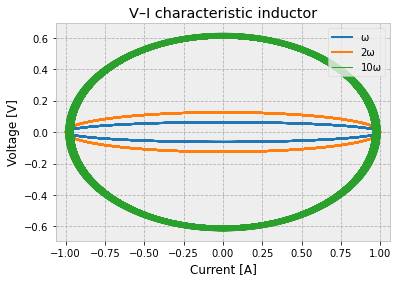

In [20]:
# =========================
# Plot: I–V characteristic
# =========================
plt.figure()

plt.title("V–I characteristic inductor")

plt.plot(i1, v1, label="ω")
plt.plot(i2, v2, label="2ω")
plt.plot(i10, v10, label="10ω", lw=1)

plt.xlabel("Current [A]")
plt.ylabel("Voltage [V]")
plt.legend()
plt.axis("equal")  # Ensures correct ellipse shape
plt.grid(True)
plt.show()

### Flux / Charge

#### Linear Memristor Model

Here, there is a problem: **there is no standard component that naturally governs the relationship between flux and charge**.

Such a component **does exist**, and the goal of this section is to introduce it. This component is the **memristor**, which defines the relationship between magnetic flux (\phi) and electric charge (q). The relation is given by:

$$\phi = M q$$

where:

* $M$ = memristance (in ohms [Ω])
* $\phi$ = magnetic flux (in webers [Wb])
* $q$ = electric charge (in coulombs [C])

Starting from this ideal memristor equation:

$$\phi = M \ q$$

and differentiating with respect to time:

$$\frac{d\phi}{dt} = M \frac{dq}{dt}$$

we obtain the voltage-current relationship:

$$v(t) = M i(t)$$

At first glance, it seems that this behaves very similarly to a resistor and that the component is linear. However, there is an important difference: **$\phi$ is not necessarily linear**, which gives the memristor its unique properties.

#### Nonlinear Memristor Model

Now, the goal is to go further in the analysis and start again from the following point.

The issue with the equation $v(t) = M i(t)$ is that it implicitly assumes a **linear relationship** between flux $\phi$ and charge $q$. In the previous section, $\phi(q)$ was considered linear.
In this section, however, **$\phi(q)$ is assumed to be nonlinear**.

$$\phi(q) \quad \text{nonlinear}$$

This leads to the definition of a **charge-dependent memristance**:

$$M(q) = \frac{d\phi(q)}{dq}$$

Therefore, $\frac{d\phi(q)}{dq}$ is no longer constant.

The voltage–current relationship can now be written as:

$$v(t) = M(q) , i(t) = \frac{d\phi(q)}{dq} , i(t)$$

#### Derivation of the Nonlinear Memristance

To compute $\frac{d\phi(q)}{dq}$, we start from the general flux–charge relationship of a memristor:

$$\phi(q) = M(q), q$$

Differentiating this expression with respect to $q$ and applying the product rule:

$$\frac{d\phi(q)}{dq} = \frac{d}{dq} \bigl(M(q), q\bigr)$$

Using:

$$(uv)' = u'v + uv'$$

we obtain:

$$\frac{d\phi(q)}{dq} = M(q) + q \frac{dM(q)}{dq}$$

Substituting this result into the voltage equation gives:

$$v(t) = \left[M(q) + q \cdot M'(q)\right] i(t)$$

#### Interpretation

This equation shows that, unlike a resistor, the voltage across a memristor depends not only on the instantaneous current but also on the **history of the charge** through the device.
As a result, the memristor is **nonlinear and history-dependent**, which is the key property that distinguishes it from resistors, capacitors, and inductors. The rest of the work is based on the equations given by {cite}`joglekarElusiveMemristorProperties2009` and {cite}`jurjPySpiceSimulatedSituLearning2024`.

In [25]:
# =========================
# Parameters
# =========================
c1 = 0                          # Constante integration
t = np.linspace(0, 100, 1000)   # Time vector (10s duration) 

In [26]:
# =========================
# Voltage and current 
# =========================
v = (np.exp(-np.cos(t)+c1))*np.sin(t)   # Tension in V
i = np.sin(t)                           # Current in A

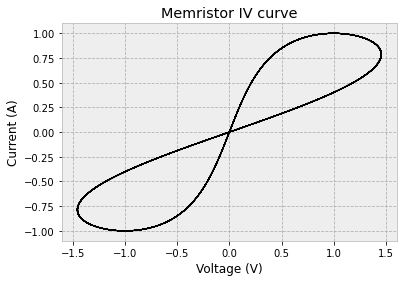

In [28]:
# =========================
# Plot: I–V characteristic
# =========================
plt.figure()

plt.title('Memristor IV curve')

plt.plot(v, i, label='V-I', c="black", lw=1)

plt.xlabel('Voltage (V)')
plt.ylabel('Current (A)')
plt.show()

In other notebooks, the goal will be to delve deeper into the equations.

## Resume

Notebook summary is resume in [](#Base_componant_vu)

```{figure} ./images/Base_componant_vu.svg
:name: Base_componant_vu
:align: center
:width: 400px

Notebook summary
```

## Reference 

```{bibliography} ../references.bib
```

## Writing Matrix

| Author | Reviewer | Approver | Section | Date 1 | Date 2 | Date 3 | General Remarks |
|--------|----------|----------|---------|--------|--------|--------|------------------|
| Sacha  | /        | /        | Entire document | 2026-02-01 | / | / | Initial draft of the full document |